In [1]:
import os
import re
import pickle as pkl
import ast
from collections import Counter
from typing import List, Tuple, Any
from tqdm import tqdm
import time

import pandas as pd
import numpy as np
import calibration as cal
import torch

from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
from llm_unsupervised_conf.metrics import *
from llm_unsupervised_conf.math_utils import stack_embeddings
from llm_unsupervised_conf.calibration import fit_predict_prob_models
from llm_unsupervised_conf.plots import DATASETS_MAP
from llm_unsupervised_conf.utils import maybe_add_verbal_conf_row, load_out_df

In [3]:
def metric_row(name, scores, correct, n_bins):
    return [
        name,
        get_ece1(scores, correct, n_bins=n_bins),
        get_ece2(scores, correct, n_bins=n_bins),
        get_mce(scores, correct, n_bins=n_bins),
        get_nll(scores, correct),
        brier_score_loss(correct, scores),
        roc_auc_score(correct, scores),
    ]


def reliability_diagram_sklearn(
    ax,
    probs,
    correct,
    n_bins=15,
    title="",
    binning="uniform",   # "uniform" (equal-width) or "quantile" (equal-mass)
    show_counts=True,
    limit_axes=False,
    ax_idx=0,
    score=None,
    show_title=True,
):
    """
    Reliability diagram using sklearn.calibration.calibration_curve.

    binning:
      - "uniform": equal-width bins on [0,1]
      - "quantile": equal-mass (quantile) bins
    """
    p = np.asarray(probs, dtype=float)
    y = np.asarray(correct, dtype=float)

    # Clean + clip
    m = np.isfinite(p) & np.isfinite(y)
    p = np.clip(p[m], 0.0, 1.0)
    y = y[m].astype(int)

    if len(p) == 0:
        ax.set_title(title + " (no data)")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        return

    prob_true, prob_pred = calibration_curve(y, p, n_bins=n_bins, strategy=binning)

    # Plot curve + y=x
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color=pal[2])
    ax.plot(prob_pred, prob_true, marker="o", linewidth=2, color=pal[0])

    if limit_axes:
        ax.set_xlim(np.min(prob_pred)*0.95, None)
        ax.set_ylim(np.min(prob_true)*0.95, None)
    else:
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    # ax.set_xlabel("Predicted probability")
    ax.set_xlabel("Confidence")
    if ax_idx == 0:
        # ax.set_ylabel("Empirical accuracy")
        ax.set_ylabel("Accuracy")

    if show_title:
        if score is None:
            ax.set_title(f"{title}")
        else:
            ax.set_title(f"{title} - ECE={round(score, 3)}")
        
    ax.grid(alpha=0.3)


    # Optional: counts per bin (computed with the same binning rule)
    if show_counts:
        ax2 = ax.twinx()

        edges = np.linspace(0.0, 1.0, n_bins + 1)

        # digitize for counts; tolerate duplicate edges by nudging
        edges2 = edges.copy()
        for i in range(1, len(edges2)):
            if edges2[i] <= edges2[i - 1]:
                edges2[i] = np.nextafter(edges2[i - 1], 1.0)
        edges2[0] = 0.0
        edges2[-1] = 1.0

        idx = np.clip(np.digitize(p, edges2, right=False) - 1, 0, n_bins - 1)
        counts = np.bincount(idx, minlength=n_bins)

        counts = counts/len(idx)

        centers = 0.5 * (edges2[:-1] + edges2[1:])
        widths = np.clip(edges2[1:] - edges2[:-1], 1e-12, None) * 0.9
        ax2.bar(centers, counts, width=widths, alpha=0.5, color=pal[3], zorder=-1)
        ax2.set_ylim(0, max(1, int(counts.max() * 1.15)))
        
        ax2.set_yticks([])
        # if ax_idx == -1:
        #     # ax2.set_ylabel("Count", rotation=270, labelpad=14)
        #     ax2.set_ylabel("Prop. Examples in Bin", rotation=270, labelpad=14)


def plot_reliability(
    con_scores,
    correct,
    logprobs,
    ans_logprobs,
    verbal_conf=None,        # <-- NEW: array in [0,1] aligned with correct, or None
    n_bins=15,
    binning="quantile",
    figsize=None,            # if None, auto based on #panels
    suptitle="Reliability diagrams",
    show_counts=False,
    limit_axes=False,
    exp_df = None,
    save_path=None
):
    """
    Reliability diagrams using sklearn calibration_curve.

    Panels:
      - Self-consistency (con_scores in [0,1])
      - exp(avg_logprobs)
      - exp(ans_logprobs)
      - (optional) verbal_conf in [0,1]
    """
    con_prob = np.asarray(con_scores, dtype=float)
    lp_prob  = np.asarray(logprobs, dtype=float)
    alp_prob = np.asarray(ans_logprobs, dtype=float)

    target_metric = "ECE2"

    vc_prob = np.asarray(verbal_conf, dtype=float)
    
    panels = [
        ("Token Probs.", lp_prob, exp_df[exp_df["Method"] == "logprob"][target_metric].tolist()[0]),
        ("Ans. Probs.", alp_prob, exp_df[exp_df["Method"] == "ans_logprob"][target_metric].tolist()[0]),
        ("Verbal Conf.", vc_prob, exp_df[exp_df["Method"] == "verbal_conf"][target_metric].tolist()[0]),
        ("Ours", con_prob, exp_df[exp_df["Method"] == OUR_METHOD][target_metric].tolist()[0]),
    ]
    n_panels = len(panels)
    if figsize is None:
        figsize = (3.25 * n_panels, 2.5)

    fig, axes = plt.subplots(1, n_panels, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    ax_idx = 0
    for ax, (title, p, score) in zip(axes, panels):
        if ax_idx+1 == len(axes):
            ax_idx = -1
        reliability_diagram_sklearn(
            ax,
            probs=p,
            correct=correct,
            n_bins=n_bins,
            title=title,
            binning=binning,
            show_counts=show_counts,
            limit_axes=limit_axes,
            ax_idx = ax_idx,
            score=score
        )
        ax_idx += 1

    fig.suptitle(suptitle, fontsize=14)


    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.show()
    

In [4]:
def run_exp(
    dataset,
    model,
    n=1000,
    k_train=100,
    temp_train=0.7,
    temp_test=0.6,
    prob_models=("ridge_clip", "split_isotonic_on_ridge", "split_isotonic_on_ridge_nrt"),   # <-- pass a list/tuple of the methods above
    include_verbal_conf=True,
    random_state=42,
    n_bins=12,
    embedding_text="question_response",
    drop_bad_rows=True,
    test_prop=0.6,
    verbose=False,
):
    """
    prob_models controls which embedding->prob models to include.
    Example:
      prob_models=["ridge_clip","ridge_logit","hgb_logit","mlp_logit","isotonic_on_ridge"]
    """

    model_name = model.split("/")[-1]

    try:
        out_df, df_save_path = load_out_df(dataset, model_name, n, temp_train, k_train, temp_test, embedding_text, drop_bad_rows)
    except:
        return

    if verbose or random_state == 0:
        print(dataset, model, "no rows", len(out_df))

    # --------------------
    # Split
    # --------------------
    train_df, test_df = train_test_split(
        out_df,
        test_size=test_prop,
        random_state=random_state,
        shuffle=True,
    )

    X_train = stack_embeddings(train_df, "embeddings")
    y_train = train_df["consistency"].astype(np.float32).to_numpy()  # target in [0,1]

    X_test = stack_embeddings(test_df, "embeddings")

    # These are for evaluation (your core metrics are vs correctness)
    con_scores = test_df["consistency"].to_numpy(dtype=float)
    correct = test_df["correct"].to_numpy(dtype=int)

    logprobs = test_df["avg_logprobs"].to_numpy(dtype=float)
    ans_logprobs = test_df["ans_logprobs"].to_numpy(dtype=float)
    lp = np.exp(logprobs)
    alp = np.exp(ans_logprobs)

    # print("lp", lp)
    # print("alp", alp)
    
    if verbose:
        print(f"Results: (accuracy={correct.mean():.4f})")


    
    
    score_sources = {
        "logprob": lp,
        "ans_logprob": alp,
        "oracle_sc": con_scores,
    }
    
    rows = [metric_row(name, scores, correct, n_bins) for name, scores in score_sources.items()]

    # --------------------
    # Embedding->prob models
    # --------------------
    prob_models = list(prob_models) if prob_models is not None else []
    preds = fit_predict_prob_models(
        X_train=X_train,
        y_train_prob=y_train,
        X_test=X_test,
        methods=prob_models,
        random_state=random_state,
    )

    for method_name, pred_probs in preds.items():
        rows.append(metric_row(method_name, pred_probs, correct, n_bins))

    # --------------------
    # Optional: verbal confidence
    # --------------------
    vc_scores = None
    if include_verbal_conf:
        rows, vc_scores = maybe_add_verbal_conf_row(
            rows, 
            df_save_path, 
            test_df, 
            correct, 
            stem_idx=6
        )

    # --------------------
    # Pack + display
    # --------------------
    exp_df = pd.DataFrame(rows, columns=["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC"])
    exp_df["Model"] = model
    exp_df["Dataset"] = dataset
    exp_df["Accuracy"] = float(correct.mean())
    exp_df["NTokens"] = np.sum(out_df["num_output_tokens"])
    exp_df = exp_df[["Model", "Dataset", "Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy", "NTokens"]]
    if verbose or random_state == 0:
        display(exp_df)

    dataset_name = DATASETS_MAP[dataset]

    plt_title = f"{dataset_name} - {model_name} (Acc={round(correct.mean(), 3)})"
    plt_save_path = f"../plots/reliability_diagrams/{dataset}_{model_name}_rel_diag.png"
    plot_reliability(
        preds[OUR_METHOD], 
        correct, 
        lp, 
        alp, 
        vc_scores, 
        binning="quantile", 
        show_counts=True,
        exp_df=exp_df,
        suptitle=plt_title,
        save_path=plt_save_path,
        n_bins=n_bins
    )

    return exp_df


In [5]:
def run_all_exps(models, datasets, n_bins=12, test_prop=0.6, seed=36):

    full_df = []
    for dataset in datasets:
        start_time = time.time()
        for model in models:
            df = run_exp(
                dataset=dataset,
                model=model,
                random_state=seed,
                n_bins=n_bins,
                test_prop=test_prop,
                embedding_text="question_response"
            )
            full_df.append(df)

    full_df = pd.concat(full_df)
    return full_df


In [6]:
OUR_METHOD = "split_isotonic_on_ridge_nrt"

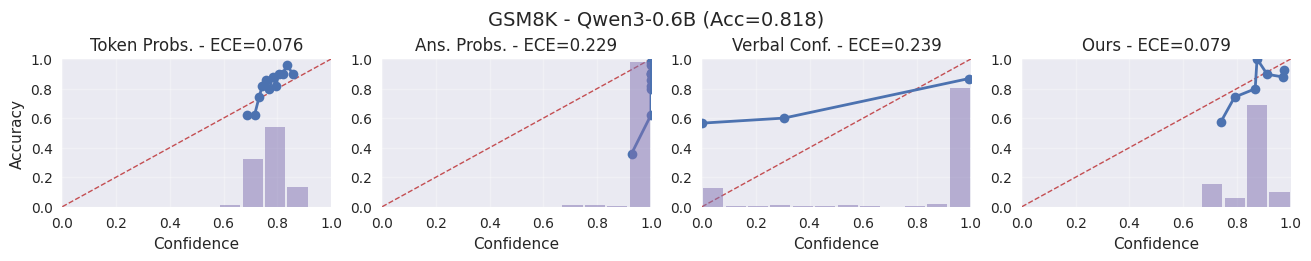

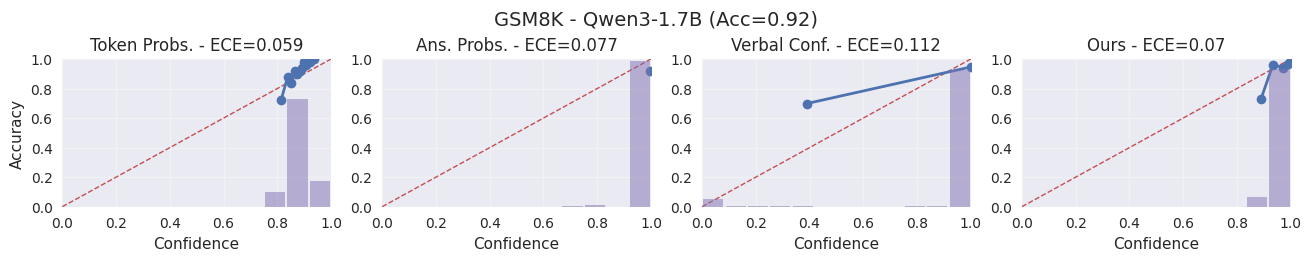

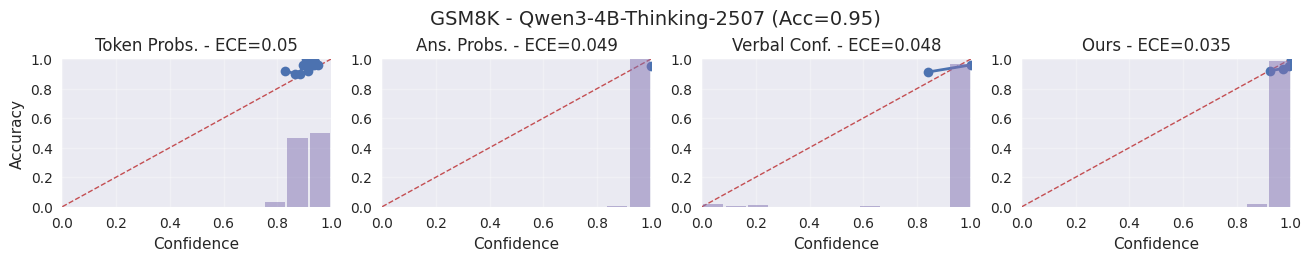

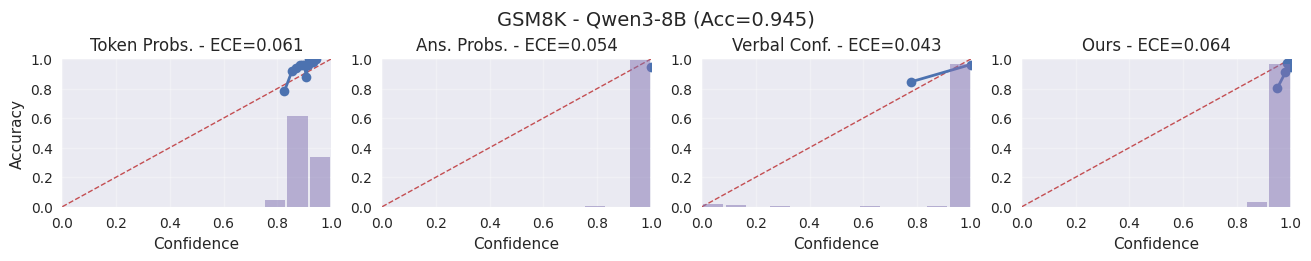

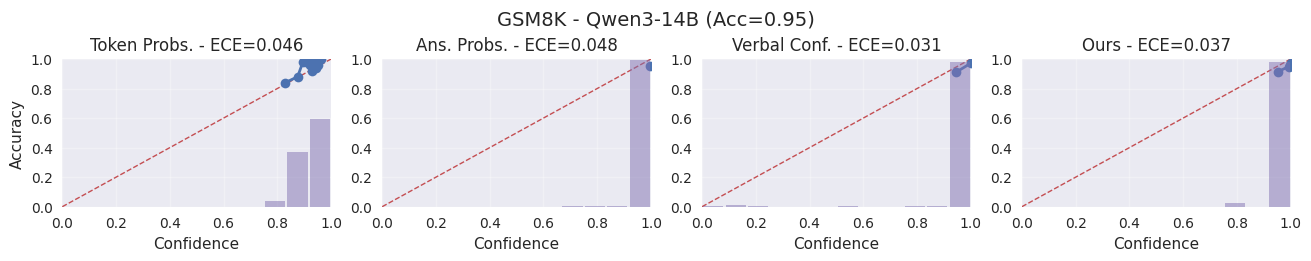

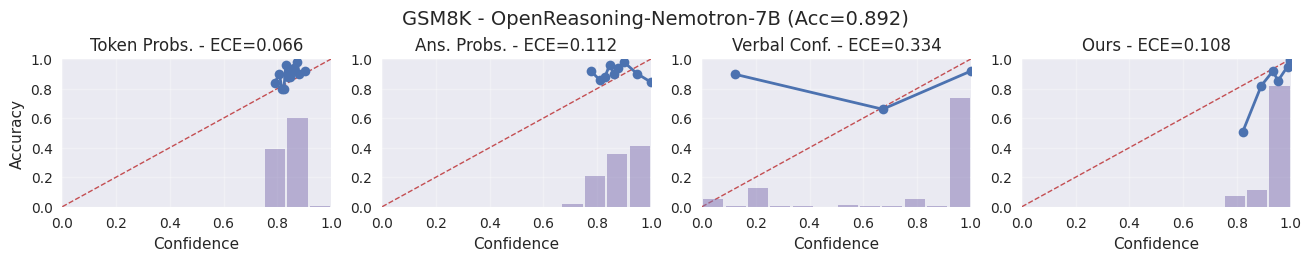

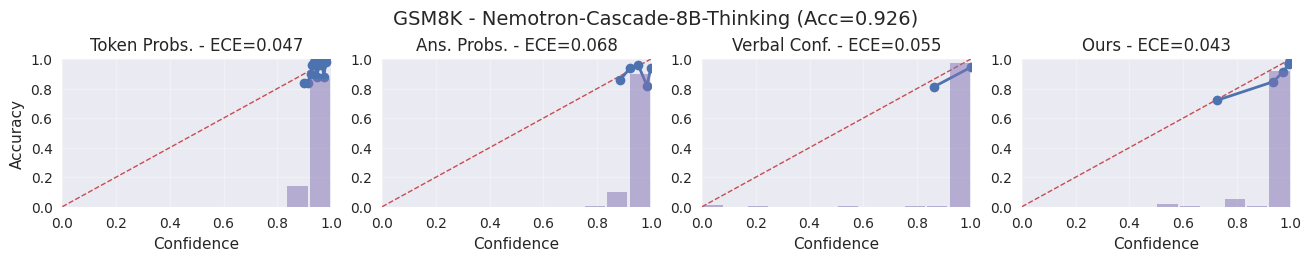

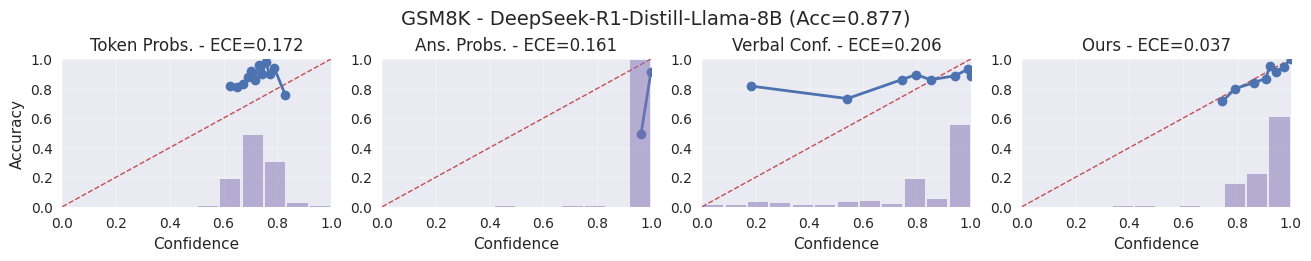

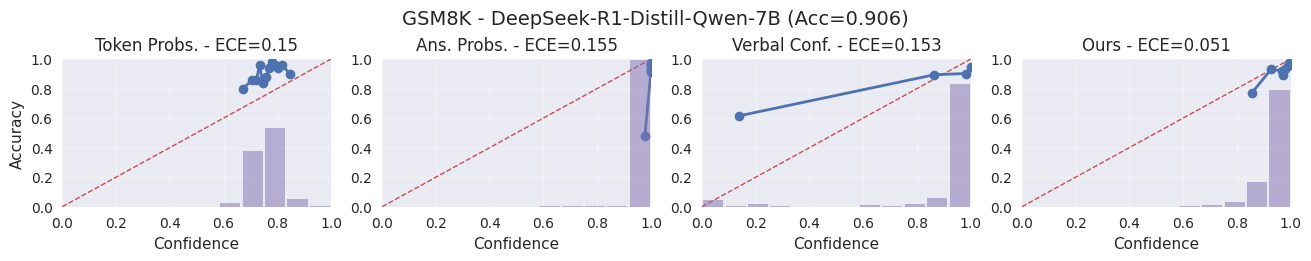

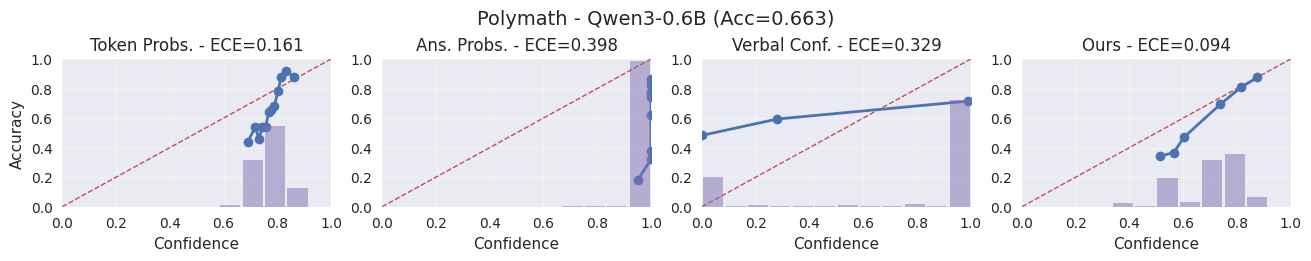

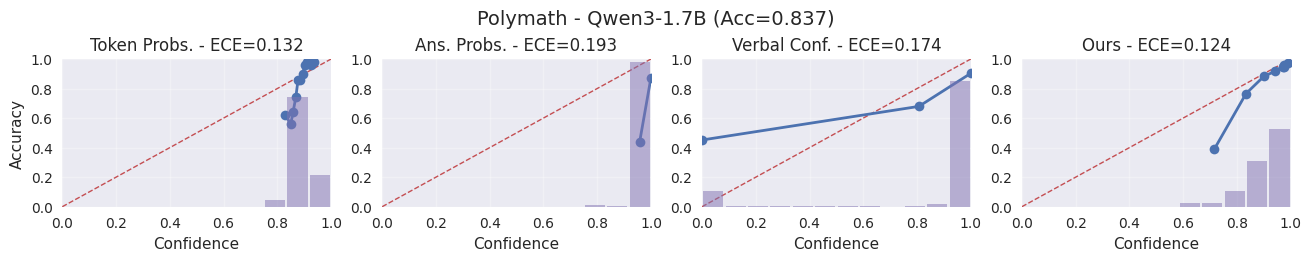

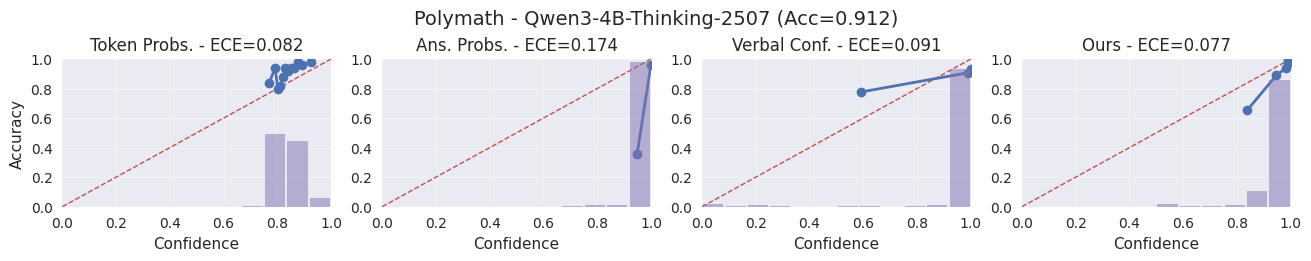

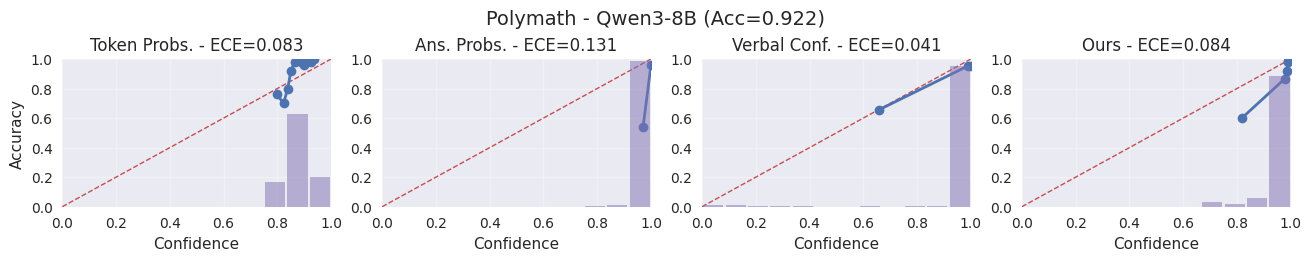

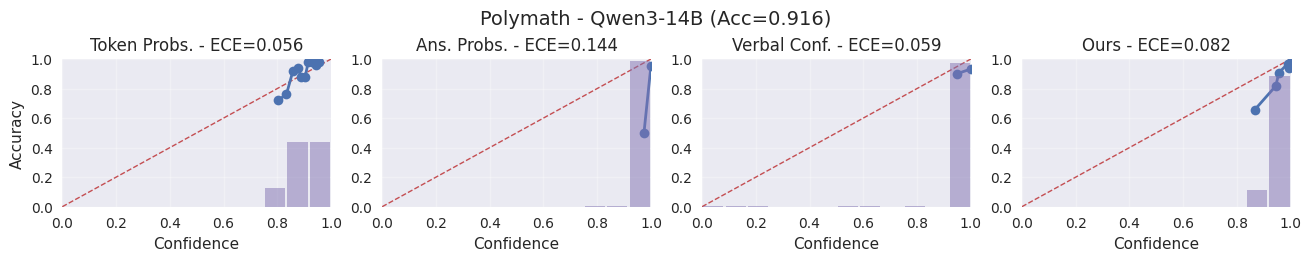

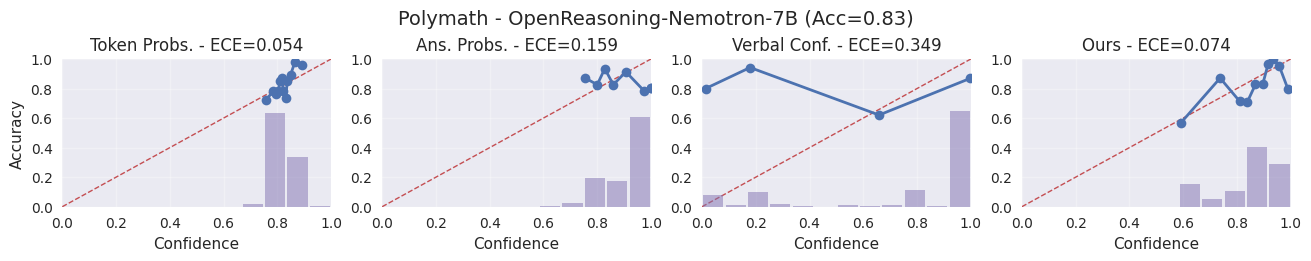

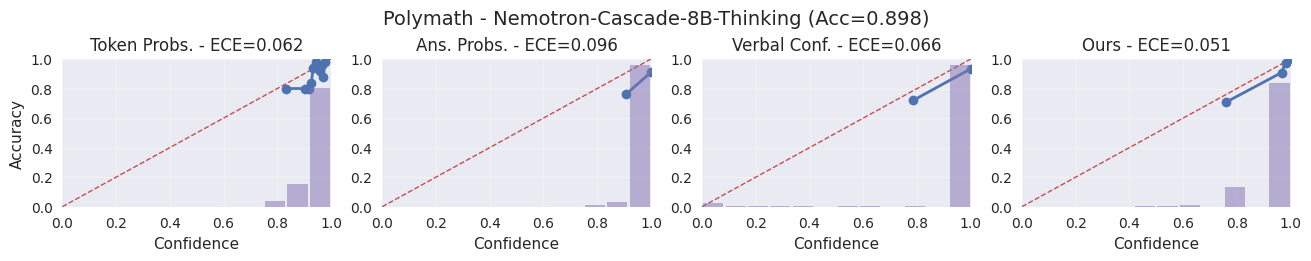

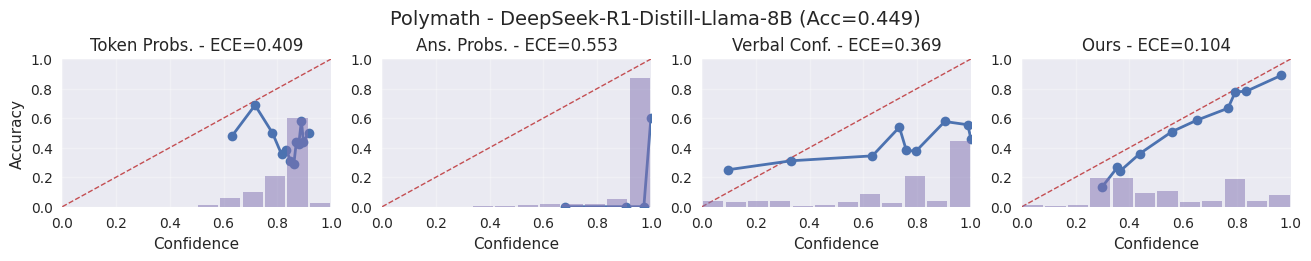

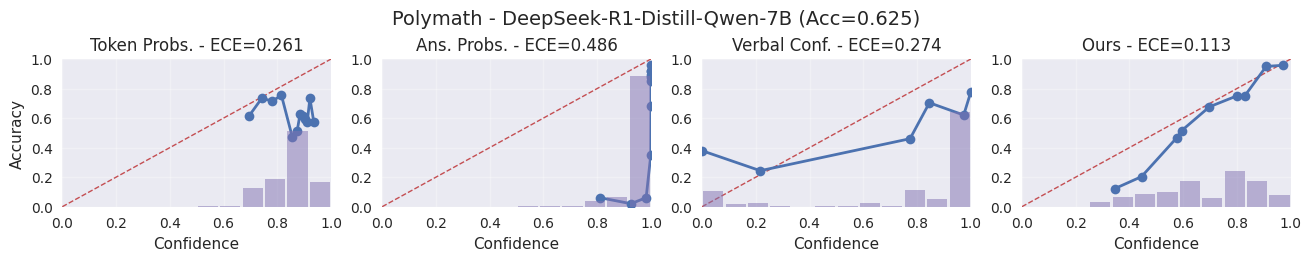

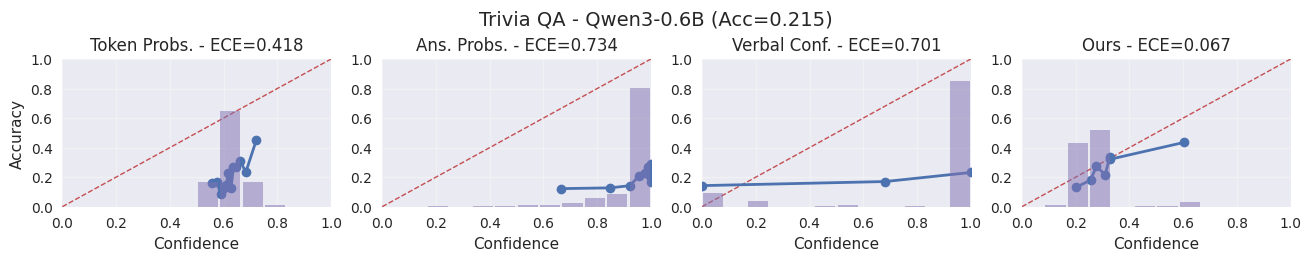

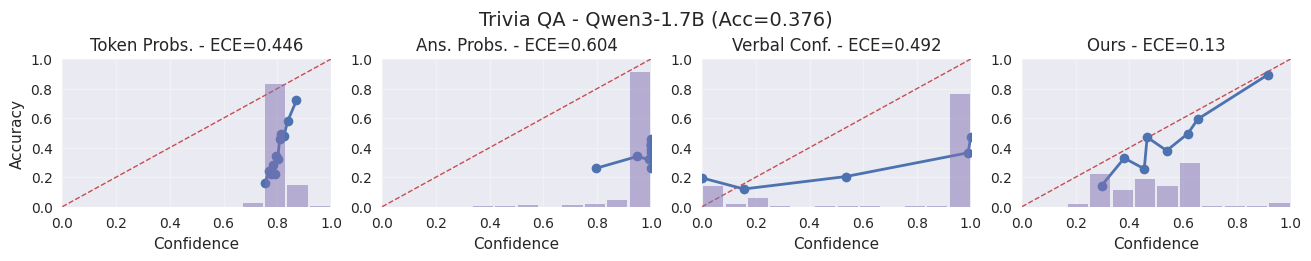

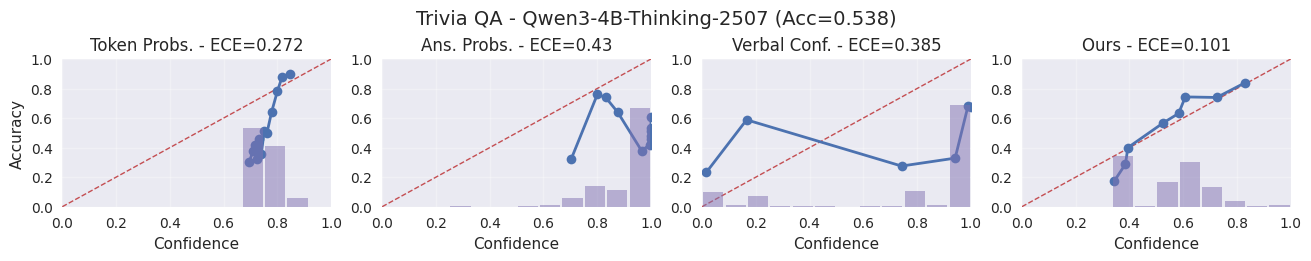

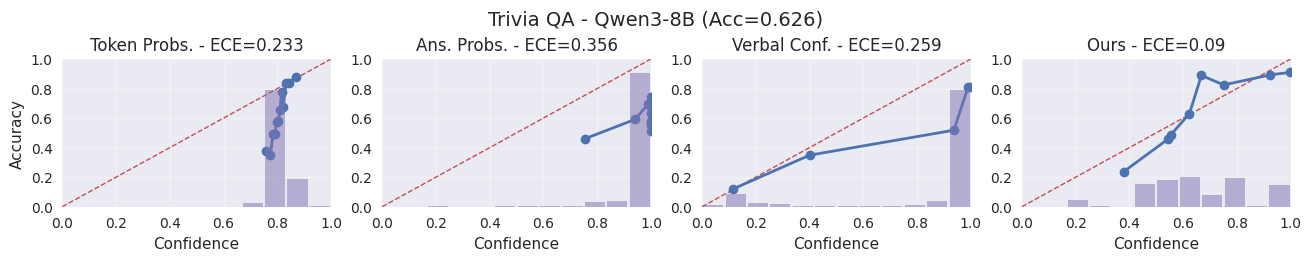

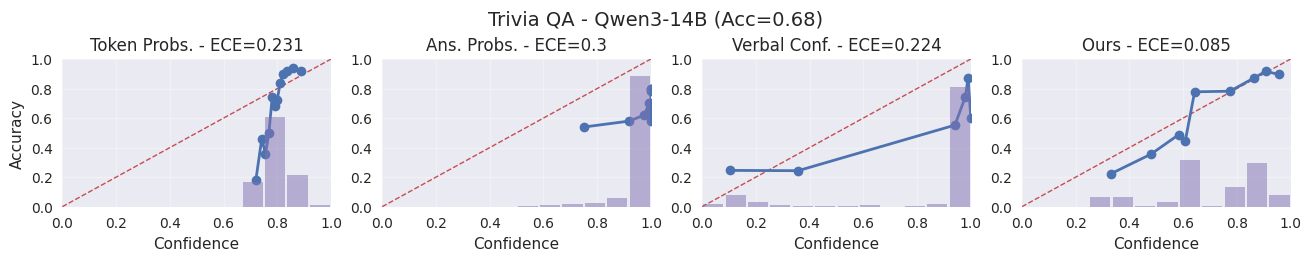

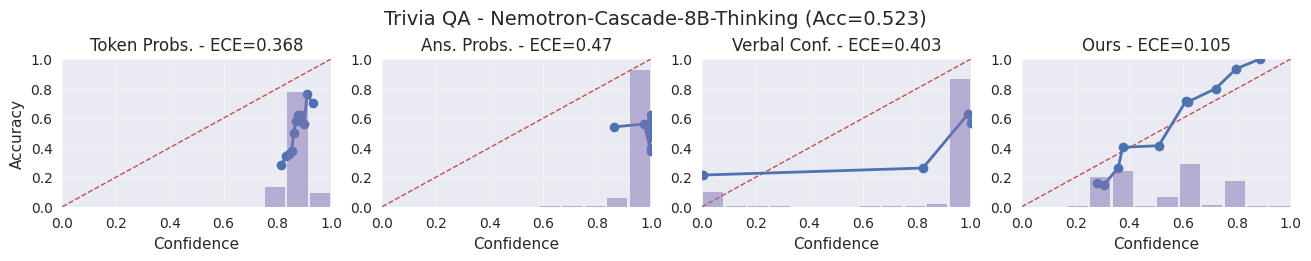

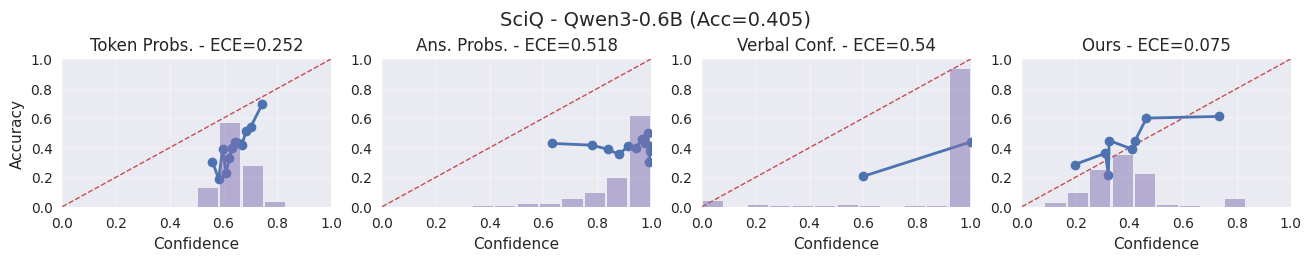

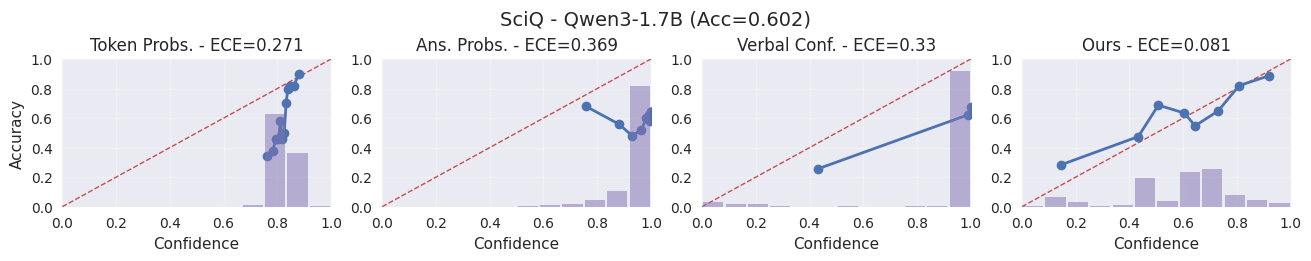

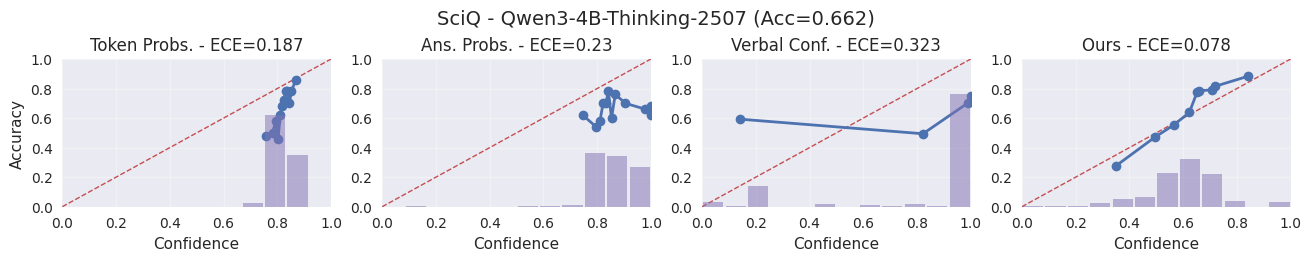

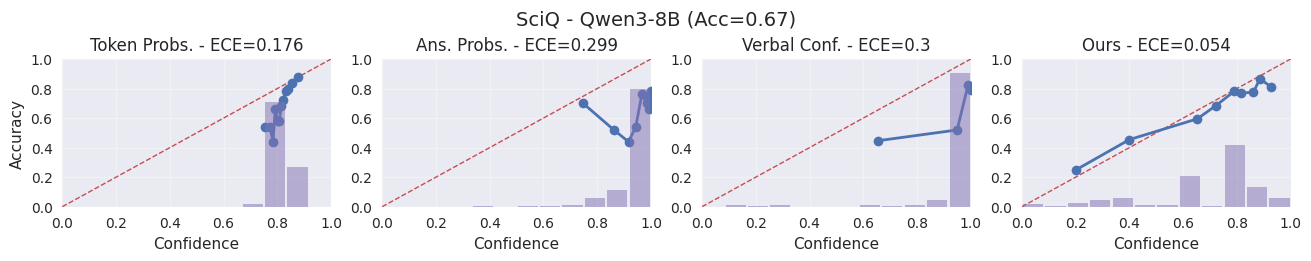

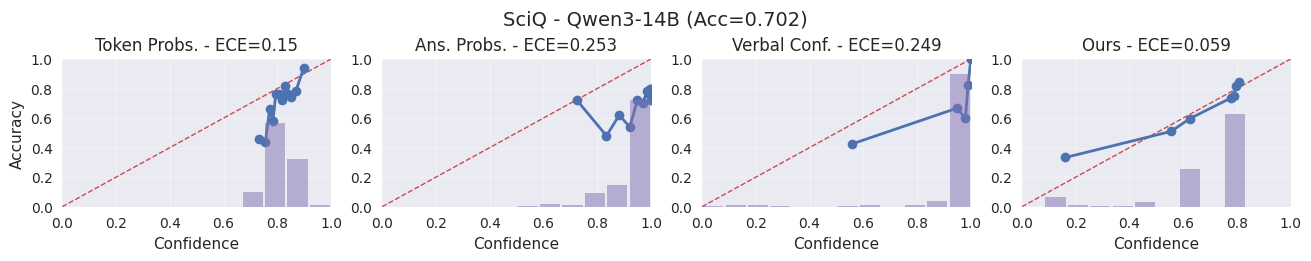

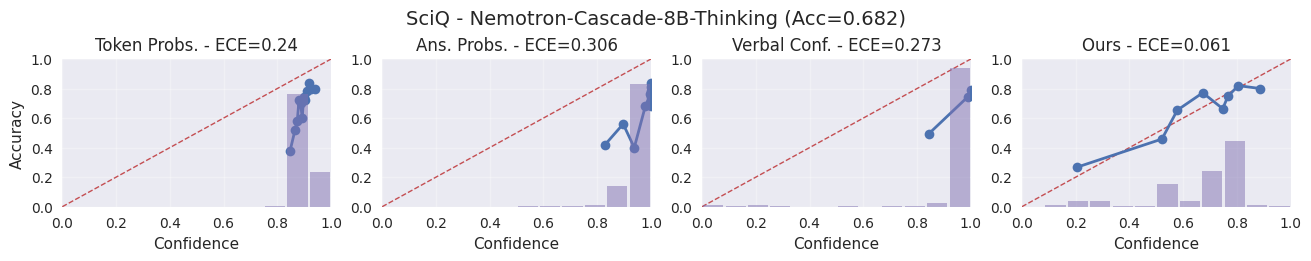

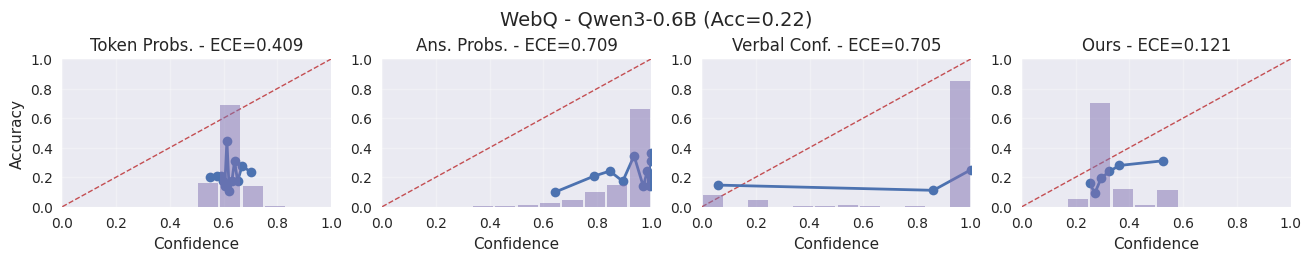

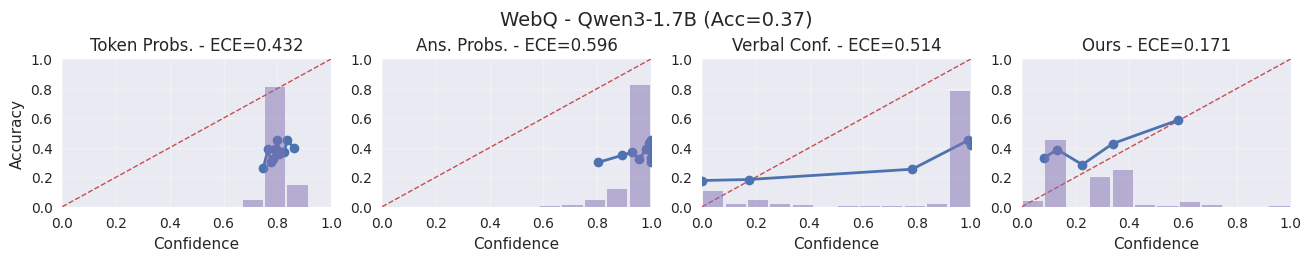

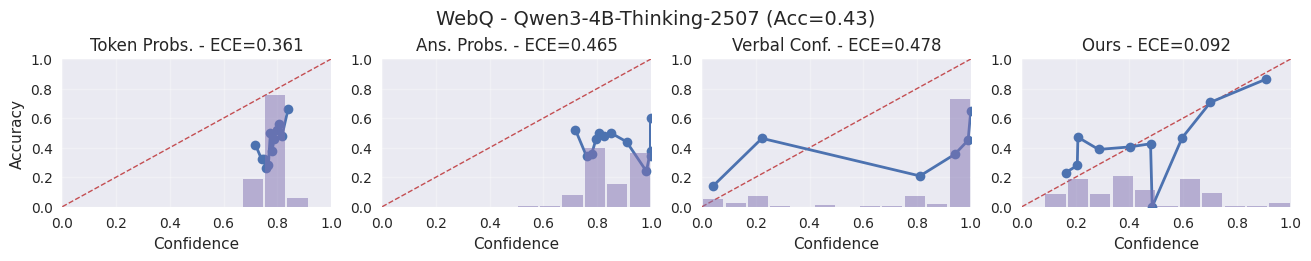

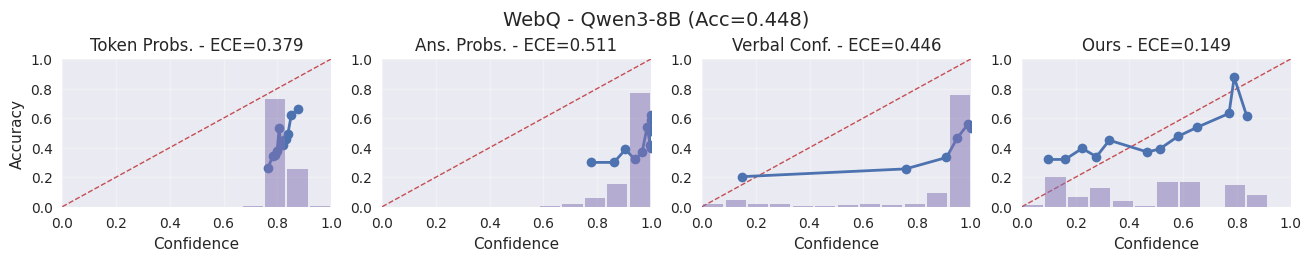

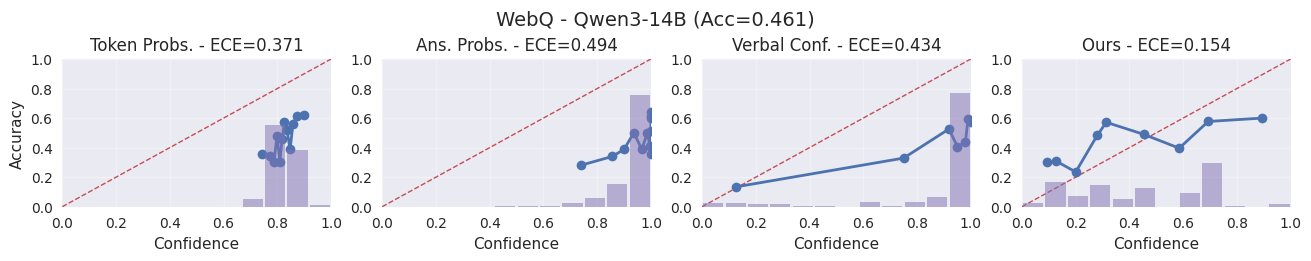

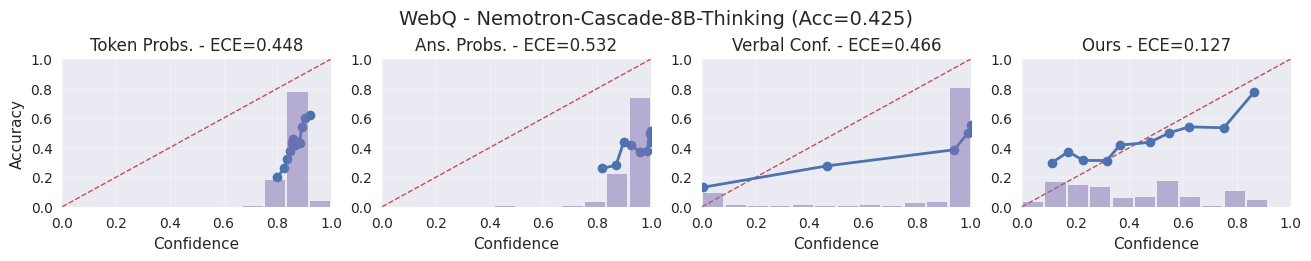

In [11]:
models = [
    "Qwen/Qwen3-0.6B", 
    "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]
datasets = [
    "gsm8k",
    "polymath",
    "trivia_qa",
    "sciq",
    "webq"
]
n_bins = 12
full_df = run_all_exps(models, datasets, test_prop=0.6, n_bins=n_bins)

In [12]:
exp_results_df = pd.read_csv("../outputs/experiment_results.csv")
exp_results_df

,id,question,ground_truth,answer,response,avg_logprobs,ans_logprobs,num_output_tokens,correct,consistency,...,vc,blackbox_ridge_clip,blackbox_split_isotonic_on_ridge,blackbox_split_isotonic_on_ridge_nrt,question_only_ridge_clip,question_only_split_isotonic_on_ridge,question_only_split_isotonic_on_ridge_nrt,model,dataset,seed
0,568,John pays for half the cost of raising a child...,265000,530000,"<think>\nOkay, let's try to figure out how muc...",-0.254461,-0.000925,3130,0,0.45,...,1.00,0.402894,0.517143,0.726000,0.610528,0.649316,0.832453,Qwen/Qwen3-0.6B,gsm8k,35
1,761,Joan is at the grocery store. She has a total ...,5,5,"<think>\nOkay, let's see. Joan wants to buy so...",-0.259715,0.000000,885,1,0.76,...,1.00,0.958991,0.938750,0.938750,0.816588,0.832453,0.936061,Qwen/Qwen3-0.6B,gsm8k,35
2,218,Ravi has some coins. He has 2 more quarters th...,350,3.50,"<think>\nOkay, let's see. So Ravi has some coi...",-0.190328,-0.110765,772,0,0.63,...,0.00,0.764609,0.765652,0.938750,1.000000,0.936061,0.936061,Qwen/Qwen3-0.6B,gsm8k,35
3,990,Grace started her own landscaping business. Sh...,567,567,"<think>\nOkay, let's see. Grace has a landscap...",-0.195661,-0.000037,1351,1,0.93,...,1.00,0.861200,0.859474,0.910000,0.856176,0.870357,0.870357,Qwen/Qwen3-0.6B,gsm8k,35
4,913,A trader made a profit of $960 after a week of...,180,180,"<think>\nOkay, let's try to figure out how muc...",-0.210819,-0.000003,581,1,0.93,...,1.00,1.000000,0.942667,0.942667,0.507751,0.557778,0.832453,Qwen/Qwen3-0.6B,gsm8k,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84591,570,what is william taft famous for?,['President of the United States'],William Taft is famous for being the only pers...,<think>\nWe are being asked what William Taft ...,-0.178161,-0.075105,403,0,0.08,...,0.99,0.000000,0.085667,0.085667,0.000000,0.010000,0.020218,nvidia/Nemotron-Cascade-8B-Thinking,webq,38
84592,895,when did the detroit pistons last win the cham...,['2004 NBA Finals'],2004,"<think>\nWe are being asked: ""When did the Det...",-0.094861,0.000000,339,1,0.65,...,1.00,0.740069,0.562000,0.562000,0.451039,0.402666,0.396977,nvidia/Nemotron-Cascade-8B-Thinking,webq,38
84593,869,where is ancient phoenician?,['Lebanon'],"\text{Lebanon, Syria, and parts of Israel",<think>\nWe are being asked about the location...,-0.112417,-0.068436,408,1,0.01,...,0.85,0.287075,0.277273,0.277196,0.000000,0.036237,0.046667,nvidia/Nemotron-Cascade-8B-Thinking,webq,38
84594,880,where did charles darwin die?,['Down House'],"\text{Down House, Kent, England",<think>\nWe are being asked where Charles Darw...,-0.107405,-0.117779,235,1,0.40,...,0.99,0.534468,0.450000,0.562000,0.472951,0.410000,0.295000,nvidia/Nemotron-Cascade-8B-Thinking,webq,38


In [22]:
def reliability_diagram_on_ax(
    ax,
    probs,
    correct,
    n_bins=15,
    title="",
    binning="uniform",   # "uniform" (equal-width) or "quantile" (equal-mass)
    show_counts=True,
    limit_axes=False,
    ax_idx=0,
    score=None,
    row_idx=0
):
    """
    Reliability diagram using sklearn.calibration.calibration_curve.

    binning:
      - "uniform": equal-width bins on [0,1]
      - "quantile": equal-mass (quantile) bins
    """
    p = np.asarray(probs, dtype=float)
    y = np.asarray(correct, dtype=float)

    # Clean + clip
    m = np.isfinite(p) & np.isfinite(y)
    p = np.clip(p[m], 0.0, 1.0)
    y = y[m].astype(int)

    if len(p) == 0:
        ax.set_title(title + " (no data)")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        return

    show_title=(row_idx == 0)
    show_x=(row_idx == 1)

    prob_true, prob_pred = calibration_curve(y, p, n_bins=n_bins, strategy=binning)

    # Plot curve + y=x
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color=pal[2])
    ax.plot(prob_pred, prob_true, marker="o", linewidth=2, color=pal[0])

    if limit_axes:
        ax.set_xlim(np.min(prob_pred)*0.95, None)
        ax.set_ylim(np.min(prob_true)*0.95, None)
    else:
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    # ax.set_xlabel("Predicted probability")
    if show_x:
        
        ax.set_xlabel("Confidence", fontsize=14)
    else:
        ax.set_xticks([])
    if ax_idx == 0:
        # ax.set_ylabel("Empirical accuracy")
        ax.set_ylabel("Accuracy", fontsize=14)

    if show_title:
        ax.set_title(f"{title}", fontsize=14)
    
    if score is not None:
        ax.text(
            0.05, 0.95, f"ECE2: {round(score,3)}",
            transform=ax.transAxes,  # Use axes-relative coordinates
            ha='left',              # Horizontal alignment: right
            va='top',                # Vertical alignment: top
            fontsize=14,
            color='k'
        )
        
    ax.grid(alpha=0.3)


    # Optional: counts per bin (computed with the same binning rule)
    if show_counts:
        ax2 = ax.twinx()

        edges = np.linspace(0.0, 1.0, n_bins + 1)

        # digitize for counts; tolerate duplicate edges by nudging
        edges2 = edges.copy()
        for i in range(1, len(edges2)):
            if edges2[i] <= edges2[i - 1]:
                edges2[i] = np.nextafter(edges2[i - 1], 1.0)
        edges2[0] = 0.0
        edges2[-1] = 1.0

        idx = np.clip(np.digitize(p, edges2, right=False) - 1, 0, n_bins - 1)
        counts = np.bincount(idx, minlength=n_bins)

        counts = counts/len(idx)

        centers = 0.5 * (edges2[:-1] + edges2[1:])
        widths = np.clip(edges2[1:] - edges2[:-1], 1e-12, None) * 0.9
        ax2.bar(centers, counts, width=widths, alpha=0.5, color=pal[3], zorder=-1)
        ax2.set_ylim(0, max(1, int(counts.max() * 1.15)))
        
        ax2.set_yticks([])
        

def plot_reliability_on_axes(
    con_scores,
    correct,
    logprobs,
    ans_logprobs,
    verbal_conf=None,        # <-- NEW: array in [0,1] aligned with correct, or None
    n_bins=15,
    binning="quantile",
    figsize=None,            # if None, auto based on #panels
    suptitle="Reliability diagrams",
    show_counts=False,
    limit_axes=False,
    exp_df = None,
    save_path=None,
    axes=None,
    row_idx=0,
    model=None,
    dataset=None
):
    """
    Reliability diagrams using sklearn calibration_curve.

    Panels:
      - Self-consistency (con_scores in [0,1])
      - exp(avg_logprobs)
      - exp(ans_logprobs)
      - (optional) verbal_conf in [0,1]
    """

    if axes is None:
        raise ValueError
    
    con_prob = np.asarray(con_scores, dtype=float)
    lp_prob  = np.asarray(logprobs, dtype=float)
    alp_prob = np.asarray(ans_logprobs, dtype=float)

    target_metric = "ECE2"

    vc_prob = np.asarray(verbal_conf, dtype=float)
    
    panels = [
        ("Token Probs.", lp_prob, None),
        ("Ans. Probs.", alp_prob, None),
        ("Verbal Conf.", vc_prob, None),
        ("Ours", con_prob, None),
    ]
    n_panels = len(panels)
    if figsize is None:
        figsize = (3.25 * n_panels, 2.5)

    ax_idx = 0
    for ax, (title, p, score) in zip(axes, panels):
        if ax_idx+1 == len(axes):
            ax_idx = -1
        reliability_diagram_on_ax(
            ax,
            probs=p,
            correct=correct,
            n_bins=n_bins,
            title=title,
            binning=binning,
            show_counts=show_counts,
            limit_axes=limit_axes,
            ax_idx = ax_idx,
            row_idx=row_idx,
            score=get_ece2(p, correct, n_bins=n_bins),
        )
        ax_idx += 1


SEED = 36


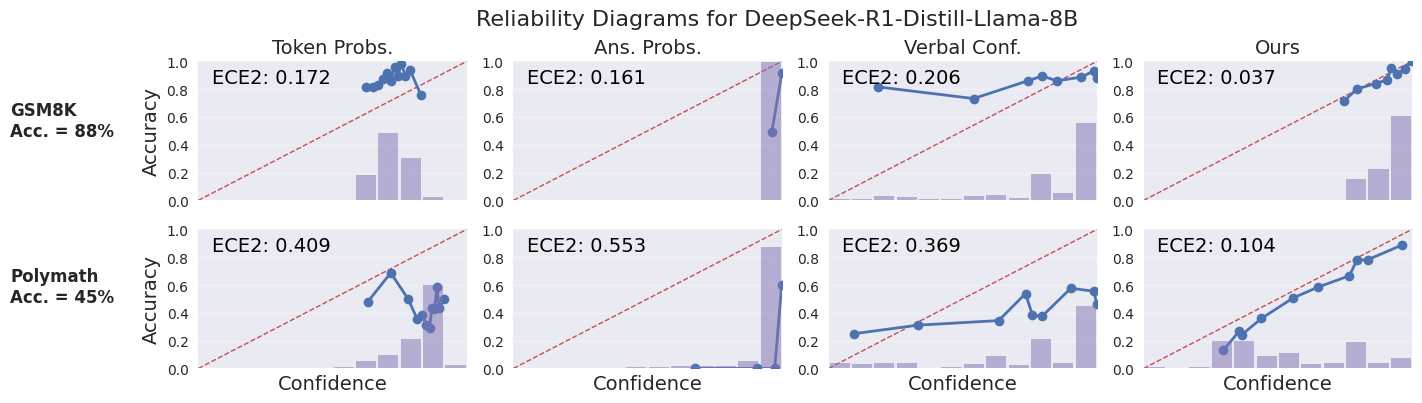

In [24]:
pairs = [
    ("deepseek-ai/DeepSeek-R1-Distill-Llama-8B","gsm8k"),
    ("deepseek-ai/DeepSeek-R1-Distill-Llama-8B","polymath"),
]

exp_seed = 36

print(f"SEED = {exp_seed}")

fig, axs = plt.subplots(
    len(pairs),4, 
    figsize=(13,4.2), 
    sharex="col"
    # constrained_layout=True
)

pairs_acc = []

exp_row = 0
for (model, dataset) in pairs:

    exp_df = exp_results_df[(exp_results_df["model"] == model) & (exp_results_df["dataset"] == dataset) & (exp_results_df["seed"] == exp_seed)]

    model_name = model.split("/")[-1]

    our_preds = exp_df[OUR_METHOD]
    
    logprobs = exp_df["avg_logprobs"].to_numpy(dtype=float)
    ans_logprobs = exp_df["ans_logprobs"].to_numpy(dtype=float)
    lp = np.exp(logprobs)
    alp = np.exp(ans_logprobs)

    vc_scores = exp_df["vc"]

    correct = exp_df["correct"]
    pairs_acc.append(np.mean(correct)*100)

    dataset_name = DATASETS_MAP[dataset]

    plt_title = f"{dataset_name} - {model_name} (Acc={round(correct.mean(), 3)})"
    plt_save_path = f"../plots/reliability_diagrams/{dataset}_{model_name}_rel_diag.png"
    plot_reliability_on_axes(
        our_preds, 
        correct, 
        lp, 
        alp, 
        vc_scores, 
        binning="quantile", 
        show_counts=True,
        exp_df=exp_df,
        suptitle=plt_title,
        save_path=plt_save_path,
        n_bins=n_bins, 
        axes=axs[exp_row, :],
        row_idx=exp_row,
        model=model_name,
        dataset=dataset_name
    )

    exp_row = exp_row + 1
    
    


for i, label in enumerate([p[1] for p in pairs]):
    # get the position of the leftmost axis in this row
    pos = axs[i, 0].get_position()
    y_center = (pos.y0 + pos.y1) / 2

    row_text = f"{DATASETS_MAP[label]}\nAcc. = {int(round(pairs_acc[i], 0))}%"

    fig.text(
        -0.09, y_center-0.02+(i*0.025), row_text,
        ha="left", va="center",
        fontsize=12,
        fontweight="bold"
    )

fig.suptitle(f"Reliability Diagrams for {model_name}", fontsize=16, y=0.95)
fig.tight_layout()

plt.savefig("../plots/deepseek_rel_diag.png", dpi=600, bbox_inches="tight")
plt.show()



In [26]:
token_df = full_df[["Model", "Dataset", "NTokens"]].groupby(["Model", "Dataset"]).mean().reset_index()

In [9]:
token_df["NTokens"].sum()

46227189.0